### Survival probability

This code plots the survival probability for the three motility states of swimming Didinium nasutum. 

**Input:**

*main_folder*: Path to folder containing the analyzed trajectories. 

*tracks_info*: The name of the folders containing individual trajectory files and the corresponding pixel size of the timelapse

**Output:**

The survival probability plot for the three motility states.

In [1]:
import os
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd
import seaborn as sns
from scipy.optimize import curve_fit
from matplotlib.lines import Line2D

In [ ]:
### Input paths
main_folder   = "C:\\Users\\kourkoul\\SCRIPTS\\Paper_scripts\\example_data\\"
tracks_info = [
    ("track_02", 68.375),
    ("track_01", 67.5),
    ("track_03", 67.5),
    ("track_04", 67.5),
    ("track_05", 68.89),
]

### Definition of color code for each state
color_spinning  =  'gray'
color_reorient = 'blue'
color_forward   = 'red'
color_dict = {
    "Spinning": color_spinning,
    "Forward": color_forward,
    "Reorientation": color_reorient
}


### Reading the input and storing in arrays
all_tracks_data = []

for track_name, px_mm in tracks_info:
    csv_path = os.path.join(main_folder, track_name, "time_statistics.csv")

    try:
        df_time_data = pd.read_csv(csv_path)
        # Add track info columns
        df_time_data["track_name"] = track_name
        df_time_data["px_mm"] = px_mm

        all_tracks_data.append(df_time_data)

    except FileNotFoundError:
        print(f"File not found: {csv_path}")
    except Exception as e:
        print(f"Error reading {csv_path}: {e}")

### Combining all tracks' data into one DataFrame
combined_df = pd.concat(all_tracks_data, ignore_index=True)


Forward - Mean: 2.302, Median: 1.200, Std: 2.913
Spinning - Mean: 11.715, Median: 3.433, Std: 15.918
Reorientation - Mean: 1.150, Median: 1.000, Std: 0.811


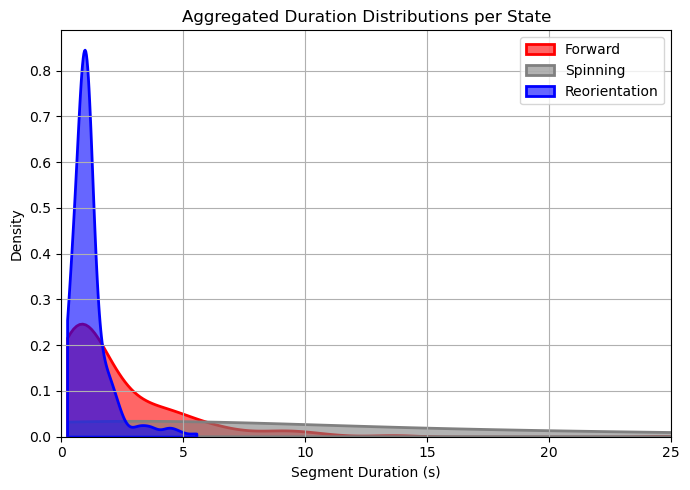

In [3]:
### Aggregate data for all tracks
all_data = pd.DataFrame()

for track in combined_df['track_name'].unique():
    df_track = combined_df[combined_df['track_name'] == track]
    data = pd.DataFrame({
        "Spinning": df_track['durations_spinning'],
        "Forward": df_track['durations_forwards'],
        "Reorientation": df_track['durations_reorient']
    })
    melted = data.melt(var_name='State', value_name='Duration')
    all_data = pd.concat([all_data, melted], ignore_index=True)

### Filter out nan or empty values 
all_data = all_data[all_data['Duration'] > 0]

### Print stats for each state
for state in ["Forward", "Spinning", "Reorientation"]:
    durations = all_data[all_data['State'] == state]['Duration']
    mean_val = durations.mean()
    median_val = durations.median()
    std_val = durations.std()
    print(f"{state} - Mean: {mean_val:.3f}, Median: {median_val:.3f}, Std: {std_val:.3f}")

### Plot KDEs for all tracks combined
plt.figure(figsize=(7,5))

for state in ["Forward", "Spinning", "Reorientation"]:
    durations = all_data[all_data['State'] == state]['Duration']
    sns.kdeplot(
        durations,
        label=state,
        fill=True,
        common_norm=False,
        alpha=0.6,
        linewidth=2,
        color=color_dict[state],
        cut=0,
        clip=(0, None)
    )
plt.xlim(0,25)
plt.xlabel("Segment Duration (s)")
plt.ylabel("Density")
plt.title("Aggregated Duration Distributions per State")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [4]:
### Definition of fit function
def plateau_exp_survival(t, A, lambd):
    return A + (1 - A) * np.exp(-lambd * t)

### Function for survival probability computation
def compute_survival_probability(durations, tau_values):
    N_Ti_0 = len(durations)
    survival_prob = []

    for tau in tau_values:
        N_Ti_tau = np.sum(durations > tau)
        survival_prob.append(N_Ti_tau / N_Ti_0)

    return np.array(survival_prob)

# Function for R^2 calculation
def compute_r_squared(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - (ss_res / ss_tot)

### Extract durations per state (all tracks combined)
durations_F = all_data[all_data['State'] == "Forward"]["Duration"].values
durations_S = all_data[all_data['State'] == "Spinning"]["Duration"].values
durations_R = all_data[all_data['State'] == "Reorientation"]["Duration"].values

tau_values = np.linspace(0, 15, 100)

### Calculating survival probabilities
survival_R = compute_survival_probability(durations_R, tau_values)
survival_S = compute_survival_probability(durations_S, tau_values)
survival_F = compute_survival_probability(durations_F, tau_values)

### Fitting
popt_R, _ = curve_fit(plateau_exp_survival, tau_values, survival_R, bounds=([0, 0], [1, np.inf]))
popt_S, _ = curve_fit(plateau_exp_survival, tau_values, survival_S, bounds=([0, 0], [1, np.inf]))
popt_F, _ = curve_fit(plateau_exp_survival, tau_values, survival_F, bounds=([0, 0], [1, np.inf]))

A_R, lambda_R = popt_R
A_S, lambda_S = popt_S
A_F, lambda_F = popt_F

### Predicted values from fits
fit_R = plateau_exp_survival(tau_values, A_R, lambda_R)
fit_S = plateau_exp_survival(tau_values, A_S, lambda_S)
fit_F = plateau_exp_survival(tau_values, A_F, lambda_F)

### Calculate R^2 values
r2_R = compute_r_squared(survival_R, fit_R)
r2_S = compute_r_squared(survival_S, fit_S)
r2_F = compute_r_squared(survival_F, fit_F)

print(f"R State: plateau = {A_R:.3f}, rate = {lambda_R:.3f}, mean lifetime (non-plateau) = {1/lambda_R:.3f}, R² = {r2_R:.3f}")
print(f"S State: plateau = {A_S:.3f}, rate = {lambda_S:.3f}, mean lifetime (non-plateau) = {1/lambda_S:.3f}, R² = {r2_S:.3f}")
print(f"F State: plateau = {A_F:.3f}, rate = {lambda_F:.3f}, mean lifetime (non-plateau) = {1/lambda_F:.3f}, R² = {r2_F:.3f}")



R State: plateau = 0.000, rate = 0.871, mean lifetime (non-plateau) = 1.148, R² = 0.934
S State: plateau = 0.336, rate = 0.407, mean lifetime (non-plateau) = 2.459, R² = 0.944
F State: plateau = 0.024, rate = 0.511, mean lifetime (non-plateau) = 1.957, R² = 0.986


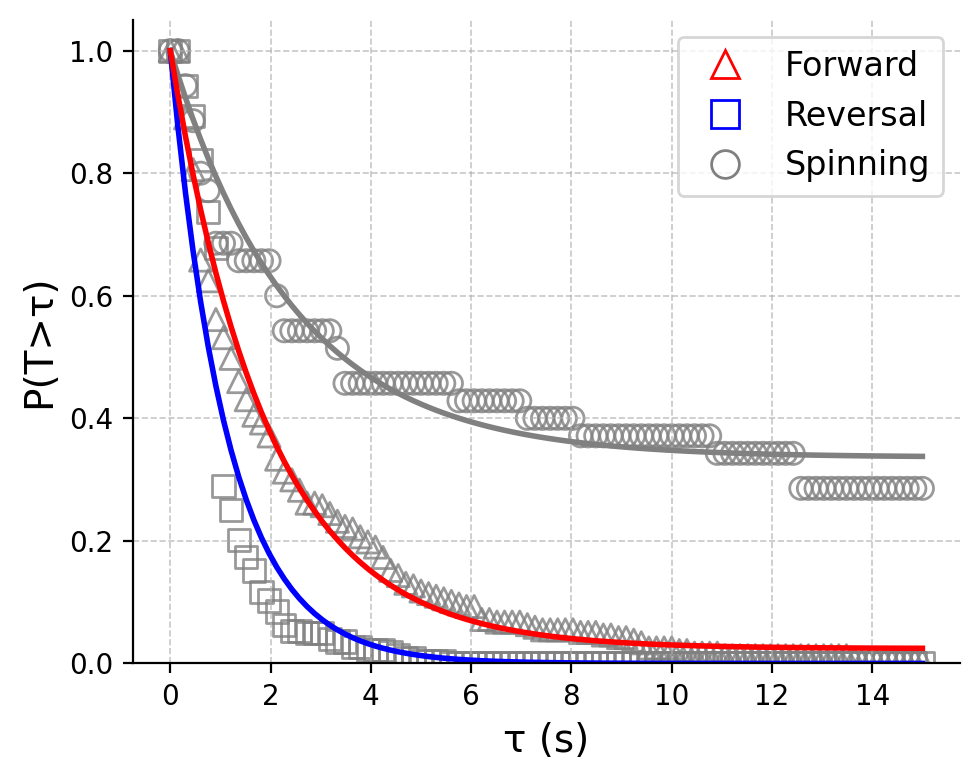

In [5]:
### Plotting the survival probability of each state (all tracks combined)
plt.figure(figsize=(5, 4), dpi=200)
tau_values = np.array(tau_values)

### Data points
plt.scatter(tau_values, survival_R, label='R State (data)', facecolors='none',
            edgecolors='gray', s=64, alpha=0.8, marker='s')
plt.scatter(tau_values, survival_S, label='S State (data)', facecolors='none',
            edgecolors='gray', s=64, alpha=0.8, marker='o')
plt.scatter(tau_values, survival_F, label='F State (data)', facecolors='none',
            edgecolors='gray', s=64, alpha=0.8, marker='^')

### Fit
plt.plot(tau_values, fit_R, label=f'R State (fit) λ={lambda_R:.3f}, R²={r2_R:.3f}',
         color=color_reorient, linestyle="solid", linewidth=2)
plt.plot(tau_values, fit_S, label=f'S State (fit) λ={lambda_S:.3f}, R²={r2_S:.3f}',
         color=color_spinning, linestyle="solid", linewidth=2)
plt.plot(tau_values, fit_F, label=f'F State (fit) λ={lambda_F:.3f}, R²={r2_F:.3f}',
         color=color_forward, linestyle="solid", linewidth=2)

plt.xlabel('\u03C4 (s)', fontsize=14, fontweight='medium')
plt.ylabel('P(T>\u03C4)', fontsize=14, fontweight='medium')

### Legend
custom_lines = [
    Line2D([0], [0], marker='^', markerfacecolor='none', markeredgecolor='red', markersize=10, linestyle='none', label='Forward'),
    Line2D([0], [0], marker='s', markerfacecolor='none', markeredgecolor='blue', markersize=10, linestyle='none', label='Reversal'),
    Line2D([0], [0], marker='o', markerfacecolor='none', markeredgecolor='gray', markersize=10, linestyle='none', label='Spinning')
]
plt.legend(handles=custom_lines, frameon=True, fontsize=12, loc='upper right')

plt.grid(True, linestyle='--', linewidth=0.6, alpha=0.7)
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.ylim(0, 1.05)
plt.tight_layout()
